                             ## Basket & Category Embedding for Recommendation System
## Objective
To transform categorical purchase data into meaningful numerical vectors (embeddings) that capture relationships between items and categories.

## Data Processing
Raw category data is cleaned and normalized.
Category strings are parsed into structured lists.

## Binary Category Matrix
A matrix is created where:
Rows = baskets (transactions)
Columns = categories
Values = 1 if category exists in basket, else 0

## Category Co-occurrence Matrix
A co-occurrence matrix is computed using matrix multiplication.
This captures how often categories appear together.

# Normalization
Log normalization (log1p) is applied to stabilize large values and improve numerical performance.

# SVD-based Embedding
Truncated Singular Value Decomposition (SVD) is applied to reduce dimensionality.
Each category is represented as a dense vector.

# Category Embedding Insight
Categories that frequently co-occur have similar vector representations.

# Basket Embedding
For each basket:
Category embeddings are averaged
Produces a single vector representing the entire basket

# Benefits
Converts sparse data into dense vectors
Captures hidden relationships
Improves recommendation accuracy
Handles cold-start scenarios (partially)
Enables use in ML/DL models
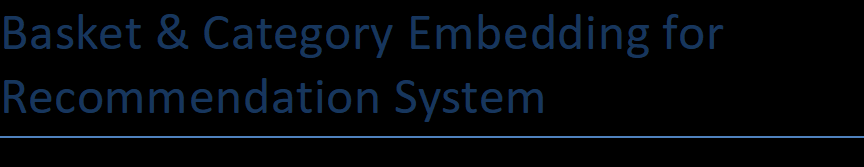
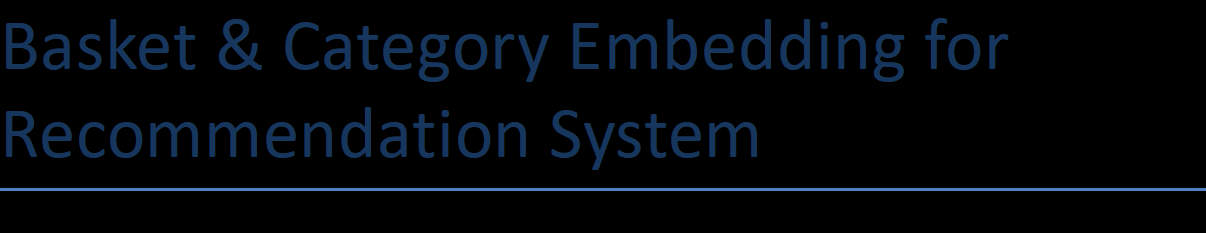
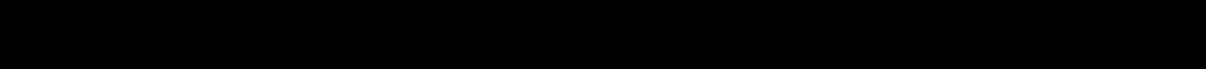

In [4]:
# =========================================
# 1. IMPORTS
# =========================================
import os
import re
import json
import ast
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD


# =========================================
# 2. DATA PATH
# =========================================
DATA_DIR = Path(r"D:\recommendation_item_API\data")

csv_files = list(DATA_DIR.glob("*.csv"))

print("CSV files found:")
for i, f in enumerate(csv_files, 1):
    print(f"{i}. {f.name}")

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found in the given folder.")

FILE_PATH = csv_files[0]
print("\nUsing file:", FILE_PATH)


# =========================================
# 3. LOAD DATA
# =========================================
df = pd.read_csv(FILE_PATH)
df.columns = [c.strip() for c in df.columns]

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())


# =========================================
# 4. HELPER FUNCTIONS
# =========================================
def normalize_text(x):
    if pd.isna(x):
        return x
    x = str(x).strip()
    x = re.sub(r"\s+", " ", x)
    return x


def parse_set_like(value):
    """
    {a, b, c} type string কে list এ convert করবে
    """
    if pd.isna(value):
        return []
    
    value = str(value).strip()
    
    if value == "":
        return []
    
    if value.startswith("{") and value.endswith("}"):
        value = value[1:-1].strip()
    
    if value == "":
        return []
    
    parts = [x.strip() for x in value.split(",")]
    parts = [x for x in parts if x != ""]
    return parts


def normalize_category(cat):
    """
    category text clean করবে
    """
    if pd.isna(cat):
        return cat
    
    cat = normalize_text(cat)
    
    parts = [p.strip() for p in cat.split("-")]
    parts = [p.capitalize() if p else p for p in parts]
    
    return "-".join(parts)


def aggregate_category_embedding(cat_list, category_to_vector, embedding_dim):
    """
    এক row এ একাধিক category থাকলে তাদের embedding এর mean নেওয়া হবে
    """
    vectors = []
    
    for cat in cat_list:
        vec = category_to_vector.get(cat)
        if vec is not None:
            vectors.append(np.array(vec, dtype=float))
    
    if len(vectors) == 0:
        return [0.0] * embedding_dim
    
    mean_vec = np.mean(vectors, axis=0)
    return mean_vec.tolist()


# =========================================
# 5. CATEGORY COLUMN CLEAN AND PARSE
# =========================================
category_col = "categorySet"

if category_col not in df.columns:
    raise ValueError(f"{category_col} column not found.")

df[category_col] = df[category_col].apply(normalize_text)

# temp parsed category list
df["_category_list"] = df[category_col].apply(parse_set_like)
df["_category_list"] = df["_category_list"].apply(
    lambda cats: [normalize_category(cat) for cat in cats]
)

print("Parsed category list sample:")
display(df[[category_col, "_category_list"]].head())


# =========================================
# 6. BUILD ALL UNIQUE CATEGORIES
# =========================================
all_categories = sorted(set(cat for cats in df["_category_list"] for cat in cats))

print("Number of unique categories:", len(all_categories))
print("Sample categories:", all_categories[:20])


# =========================================
# 7. ROW X CATEGORY BINARY MATRIX
# =========================================
row_cat_matrix = pd.DataFrame(
    0,
    index=df.index,
    columns=all_categories,
    dtype=np.int32
)

for idx, cats in df["_category_list"].items():
    for cat in cats:
        row_cat_matrix.at[idx, cat] = 1

print("Row category matrix shape:", row_cat_matrix.shape)
print("Row matrix dtype:", row_cat_matrix.dtypes.unique())
display(row_cat_matrix.head())


# =========================================
# 8. CATEGORY CO OCCURRENCE MATRIX
# =========================================
cooc_matrix = row_cat_matrix.T.dot(row_cat_matrix).astype(np.int32)

# diagonal zero
np.fill_diagonal(cooc_matrix.values, 0)

print("Co occurrence shape:", cooc_matrix.shape)
print("Co occurrence min:", cooc_matrix.min().min())
print("Co occurrence max:", cooc_matrix.max().max())

neg_count = (cooc_matrix < 0).sum().sum()
print("Negative values in cooc_matrix:", neg_count)

display(cooc_matrix.iloc[:10, :10])


# =========================================
# 9. SAFE NORMALIZATION
# =========================================
# log1p এর আগে নিশ্চিত হচ্ছি negative কিছু নেই
if (cooc_matrix < 0).sum().sum() > 0:
    raise ValueError("cooc_matrix এ negative value আছে. সম্ভবত dtype overflow হয়েছে.")

cooc_for_svd = np.log1p(cooc_matrix.astype(np.float64))

cooc_matrix = row_cat_matrix.T.dot(row_cat_matrix).astype(np.int32)

np.fill_diagonal(cooc_matrix.values, 0)

print("Co occurrence shape:", cooc_matrix.shape)
print("Co occurrence min:", cooc_matrix.min().min())
print("Co occurrence max:", cooc_matrix.max().max())

neg_count = (cooc_matrix < 0).sum().sum()
print("Negative values in cooc_matrix:", neg_count)

if neg_count > 0:
    raise ValueError("cooc_matrix এ negative value আছে, dtype overflow হয়েছে।")

cooc_for_svd = np.log1p(cooc_matrix.astype(np.float64))

nan_count = np.isnan(cooc_for_svd.to_numpy()).sum()
print("NaN count after log1p:", nan_count)

if nan_count > 0:
    raise ValueError("log1p এর পরে NaN পাওয়া গেছে।")


# =========================================
# 10. SVD BASED CATEGORY EMBEDDING
# =========================================
n_categories = cooc_for_svd.shape[0]
embedding_dim = min(8, max(2, n_categories - 1))

svd = TruncatedSVD(n_components=embedding_dim, random_state=42)
category_embeddings = svd.fit_transform(cooc_for_svd)

cat_emb_df = pd.DataFrame(
    category_embeddings,
    index=cooc_for_svd.index,
    columns=[f"cat_emb_{i}" for i in range(embedding_dim)]
)

cat_emb_df["category_embedding"] = cat_emb_df.values.tolist()

print("Category embedding shape:", cat_emb_df.shape)
print("Explained variance ratio sum:", svd.explained_variance_ratio_.sum())
display(cat_emb_df.head())

print("Explained variance ratio sum:", svd.explained_variance_ratio_.sum())


# =========================================
# 11. CATEGORY TO VECTOR LOOKUP
# =========================================
category_to_vector = cat_emb_df["category_embedding"].to_dict()

print("Lookup table size:", len(category_to_vector))


# =========================================
# 12. CREATE BASKET CATEGORY EMBEDDING
# =========================================
df["basket_category_embedding"] = df["_category_list"].apply(
    lambda cats: aggregate_category_embedding(cats, category_to_vector, embedding_dim)
)

display(df[[category_col, "basket_category_embedding"]].head(10))


# =========================================
# 13. JSON STRING CONVERT
# =========================================
df["basket_category_embedding"] = df["basket_category_embedding"].apply(
    lambda x: json.dumps([round(float(v), 6) for v in x]) if x is not None else None
)

display(df[[category_col, "basket_category_embedding"]].head(10))


# =========================================
# 14. FINAL DATAFRAME PREPARE
# =========================================
df_final_embedded = df.drop(columns=["_category_list"]).copy()

print("Final shape:", df_final_embedded.shape)
display(df_final_embedded.head())


# =========================================
# 15. SAVE FINAL DATASET
# =========================================
OUTPUT_FILE = DATA_DIR / "customer_purchase_pattern_history_date_only_with_basket_category_embedding.csv"
df_final_embedded.to_csv(OUTPUT_FILE, index=False)

print("Saved:", OUTPUT_FILE)


# =========================================
# 16. SAVE CATEGORY LOOKUP TABLE
# =========================================
cat_lookup = cat_emb_df.reset_index().rename(columns={"index": "category"})

cat_lookup["category_embedding"] = cat_lookup["category_embedding"].apply(
    lambda x: json.dumps([round(float(v), 6) for v in x])
)

LOOKUP_FILE = DATA_DIR / "category_embedding_lookup_from_customer_history.csv"
cat_lookup.to_csv(LOOKUP_FILE, index=False)

print("Saved:", LOOKUP_FILE)
display(cat_lookup.head())

CSV files found:
1. customer_purchase_pattern_history_date_only_with_basket_category_embedding (1).csv
2. customer_purchase_pattern_history_final.csv
3. item_catalog.csv
4. large_dataset_chronological.csv
5. main_data.csv

Using file: D:\recommendation_item_API\data\customer_purchase_pattern_history_date_only_with_basket_category_embedding (1).csv
Shape: (6108, 15)
Columns: ['customerId', 'purchaseDate', 'categorySet', 'itemIdSet', 'itemNameSet', 'season', 'seasonLabel', 'isHoliday', 'isFestival', 'timeSlot', 'timeSlotLabel', 'monthPartLabel', 'weekOfMonth', 'embedded_cat', 'basket_category_embedding']


,customerId,purchaseDate,categorySet,itemIdSet,itemNameSet,season,seasonLabel,isHoliday,isFestival,timeSlot,timeSlotLabel,monthPartLabel,weekOfMonth,embedded_cat,basket_category_embedding
0,23561,01-01-25,"{Dairy-Other, Bakery-Bread, Beverage-Hot}","{7075, 27, 6814}","{Herman Peanut Butter-340gm, Pran Toast-250g, ...",Winter,1,0,0,Morning,1,1,1,"[274.294032, -226.995335, -93.049201, 19.95413...","[29.928769, -0.264688, -0.632273, -0.389245, 0..."
1,23569,01-01-25,"{Pantry-DryFood, Fruits-Fresh, Bakery-Bread, D...","{25474, 15131, 13786, 7017, 6815, 31849, 13352}","{Lassa Special Semai-500g(Pkt), Atta Fruits, C...",Winter,1,0,0,Morning,1,1,1,"[267.090465, -107.99092, -62.485219, 24.428983...","[28.234124, 0.153048, -0.106894, -0.015198, 0...."
2,23527,01-01-25,"{Pantry-Oils, Household-Cleaning, Fish-Fresh, ...","{32441, 2306, 13922, 2364, 952, 30743, 32269}","{Ela vista pomace olive oil 250 ml, Harpic Tot...",Winter,1,0,0,Afternoon,3,1,1,"[192.558794, -92.786054, 63.207407, -85.940073...","[30.191856, -0.558436, 0.644018, 0.44081, -0.7..."
3,23433,01-01-25,"{Spices-Cooking, Veg-Cooking, Pantry-DryFood}","{878, 704, 15104, 31328, 14964}","{Radhuni Spices (Corinder)-100gm, Radhuni Spic...",Winter,1,0,0,Afternoon,3,1,1,"[71.736065, -174.945709, 115.666275, -59.86488...","[31.248554, -0.560331, -0.796425, -1.717897, -..."
4,23494,01-01-25,"{Pantry-Sweeteners, Personal-Care-Oral, Househ...","{15180, 2220, 2364, 13793, 708, 2043, 12655}","{Akher Sugar -1kg, Ambition Tooth brush, Rok T...",Winter,1,0,0,Afternoon,3,1,1,"[152.481133, -52.354355, 107.732045, -131.0783...","[29.365952, 0.023257, -0.854166, -0.450602, 0...."


Parsed category list sample:


,categorySet,_category_list
0,"{Dairy-Other, Bakery-Bread, Beverage-Hot}","[Dairy-Other, Bakery-Bread, Beverage-Hot]"
1,"{Pantry-DryFood, Fruits-Fresh, Bakery-Bread, D...","[Pantry-Dryfood, Fruits-Fresh, Bakery-Bread, D..."
2,"{Pantry-Oils, Household-Cleaning, Fish-Fresh, ...","[Pantry-Oils, Household-Cleaning, Fish-Fresh, ..."
3,"{Spices-Cooking, Veg-Cooking, Pantry-DryFood}","[Spices-Cooking, Veg-Cooking, Pantry-Dryfood]"
4,"{Pantry-Sweeteners, Personal-Care-Oral, Househ...","[Pantry-Sweeteners, Personal-Care-Oral, Househ..."


Number of unique categories: 43
Sample categories: ['Bakery-Bread', 'Beverage-Carbonated', 'Beverage-Hot', 'Beverage-Juice', 'Beverage-Water', 'Chocolates-Sweets', 'Clothing-Accessories', 'Clothing-Casual', 'Clothing-Traditional', 'Dairy-Milk', 'Dairy-Other', 'Desserts-Traditional', 'Dry-Fruits', 'Fish-Fresh', 'Fruits-Fresh', 'Household-Aircare', 'Household-Cleaning', 'Household-Kitchen', 'Household-Laundry', 'Household-Tissue']
Row category matrix shape: (6108, 43)
Row matrix dtype: [dtype('int32')]


...

,categorySet,basket_category_embedding
0,"{Dairy-Other, Bakery-Bread, Beverage-Hot}","[29.928769, -0.264688, -0.632273, -0.389245, 0..."
1,"{Pantry-DryFood, Fruits-Fresh, Bakery-Bread, D...","[28.234124, 0.153048, -0.106894, -0.015198, 0...."
2,"{Pantry-Oils, Household-Cleaning, Fish-Fresh, ...","[30.191856, -0.558436, 0.644018, 0.44081, -0.7..."
3,"{Spices-Cooking, Veg-Cooking, Pantry-DryFood}","[31.248554, -0.560331, -0.796425, -1.717897, -..."
4,"{Pantry-Sweeteners, Personal-Care-Oral, Househ...","[29.365952, 0.023257, -0.854166, -0.450602, 0...."
5,"{Household-Utility, Fruits-Fresh, Personal-Car...","[25.706331, 0.218619, 0.191138, 0.060522, -0.0..."
6,"{Chocolates-Sweets, Household-Utility, Persona...","[27.692942, -0.031742, -0.238659, -0.074706, 0..."
7,"{Veg-Cooking, Pantry-Grains, Pantry-Pulses, Pe...","[28.696574, 0.177345, 0.291792, -0.12702, -0.0..."
8,"{Veg-Cooking, Spices-Cooking, Dairy-Milk, Meat...","[31.71348, 0.085276, -1.204987, -0.266164, -0...."
9,"{Fish-Fresh, Spices-Cooking, Desserts-Traditio...","[30.731593, -0.04701, -0.568951, -1.111268, -0..."


Final shape: (6108, 15)


,customerId,purchaseDate,categorySet,itemIdSet,itemNameSet,season,seasonLabel,isHoliday,isFestival,timeSlot,timeSlotLabel,monthPartLabel,weekOfMonth,embedded_cat,basket_category_embedding
0,23561,01-01-25,"{Dairy-Other, Bakery-Bread, Beverage-Hot}","{7075, 27, 6814}","{Herman Peanut Butter-340gm, Pran Toast-250g, ...",Winter,1,0,0,Morning,1,1,1,"[274.294032, -226.995335, -93.049201, 19.95413...","[29.928769, -0.264688, -0.632273, -0.389245, 0..."
1,23569,01-01-25,"{Pantry-DryFood, Fruits-Fresh, Bakery-Bread, D...","{25474, 15131, 13786, 7017, 6815, 31849, 13352}","{Lassa Special Semai-500g(Pkt), Atta Fruits, C...",Winter,1,0,0,Morning,1,1,1,"[267.090465, -107.99092, -62.485219, 24.428983...","[28.234124, 0.153048, -0.106894, -0.015198, 0...."
2,23527,01-01-25,"{Pantry-Oils, Household-Cleaning, Fish-Fresh, ...","{32441, 2306, 13922, 2364, 952, 30743, 32269}","{Ela vista pomace olive oil 250 ml, Harpic Tot...",Winter,1,0,0,Afternoon,3,1,1,"[192.558794, -92.786054, 63.207407, -85.940073...","[30.191856, -0.558436, 0.644018, 0.44081, -0.7..."
3,23433,01-01-25,"{Spices-Cooking, Veg-Cooking, Pantry-DryFood}","{878, 704, 15104, 31328, 14964}","{Radhuni Spices (Corinder)-100gm, Radhuni Spic...",Winter,1,0,0,Afternoon,3,1,1,"[71.736065, -174.945709, 115.666275, -59.86488...","[31.248554, -0.560331, -0.796425, -1.717897, -..."
4,23494,01-01-25,"{Pantry-Sweeteners, Personal-Care-Oral, Househ...","{15180, 2220, 2364, 13793, 708, 2043, 12655}","{Akher Sugar -1kg, Ambition Tooth brush, Rok T...",Winter,1,0,0,Afternoon,3,1,1,"[152.481133, -52.354355, 107.732045, -131.0783...","[29.365952, 0.023257, -0.854166, -0.450602, 0...."


Saved: D:\recommendation_item_API\data\customer_purchase_pattern_history_date_only_with_basket_category_embedding.csv
Saved: D:\recommendation_item_API\data\category_embedding_lookup_from_customer_history.csv


,category,cat_emb_0,cat_emb_1,cat_emb_2,cat_emb_3,cat_emb_4,cat_emb_5,cat_emb_6,cat_emb_7,category_embedding
0,Bakery-Bread,30.500512,-0.312345,-1.336538,0.171504,1.265434,-0.221737,-2.422268,-1.024791,"[30.500512, -0.312345, -1.336538, 0.171504, 1...."
1,Beverage-Carbonated,30.793406,0.582054,2.320642,-1.194838,0.826971,-1.544423,1.249234,-0.971547,"[30.793406, 0.582054, 2.320642, -1.194838, 0.8..."
2,Beverage-Hot,29.132634,0.224027,0.067448,-0.667184,-0.053071,0.364866,0.603695,0.191561,"[29.132634, 0.224027, 0.067448, -0.667184, -0...."
3,Beverage-Juice,31.321391,0.378736,0.439785,-0.637943,0.784723,-1.583087,-2.383535,2.169788,"[31.321391, 0.378736, 0.439785, -0.637943, 0.7..."
4,Beverage-Water,22.344446,0.596863,0.331393,-0.024937,0.778449,0.414786,-0.005348,-0.207390,"[22.344446, 0.596863, 0.331393, -0.024937, 0.7..."


In [5]:
df_final = df_final_embedded.drop(columns=["embedded_cat"], errors="ignore").copy()

In [6]:
print(df_final.columns.tolist())

['customerId', 'purchaseDate', 'categorySet', 'itemIdSet', 'itemNameSet', 'season', 'seasonLabel', 'isHoliday', 'isFestival', 'timeSlot', 'timeSlotLabel', 'monthPartLabel', 'weekOfMonth', 'basket_category_embedding']


In [7]:
OUTPUT_FILE = DATA_DIR / "customer_purchase_pattern_history_final.csv"
df_final.to_csv(OUTPUT_FILE, index=False)

print("Saved:", OUTPUT_FILE)
display(df_final.head())

Saved: D:\recommendation_item_API\data\customer_purchase_pattern_history_final.csv


,customerId,purchaseDate,categorySet,itemIdSet,itemNameSet,season,seasonLabel,isHoliday,isFestival,timeSlot,timeSlotLabel,monthPartLabel,weekOfMonth,basket_category_embedding
0,23561,01-01-25,"{Dairy-Other, Bakery-Bread, Beverage-Hot}","{7075, 27, 6814}","{Herman Peanut Butter-340gm, Pran Toast-250g, ...",Winter,1,0,0,Morning,1,1,1,"[29.928769, -0.264688, -0.632273, -0.389245, 0..."
1,23569,01-01-25,"{Pantry-DryFood, Fruits-Fresh, Bakery-Bread, D...","{25474, 15131, 13786, 7017, 6815, 31849, 13352}","{Lassa Special Semai-500g(Pkt), Atta Fruits, C...",Winter,1,0,0,Morning,1,1,1,"[28.234124, 0.153048, -0.106894, -0.015198, 0...."
2,23527,01-01-25,"{Pantry-Oils, Household-Cleaning, Fish-Fresh, ...","{32441, 2306, 13922, 2364, 952, 30743, 32269}","{Ela vista pomace olive oil 250 ml, Harpic Tot...",Winter,1,0,0,Afternoon,3,1,1,"[30.191856, -0.558436, 0.644018, 0.44081, -0.7..."
3,23433,01-01-25,"{Spices-Cooking, Veg-Cooking, Pantry-DryFood}","{878, 704, 15104, 31328, 14964}","{Radhuni Spices (Corinder)-100gm, Radhuni Spic...",Winter,1,0,0,Afternoon,3,1,1,"[31.248554, -0.560331, -0.796425, -1.717897, -..."
4,23494,01-01-25,"{Pantry-Sweeteners, Personal-Care-Oral, Househ...","{15180, 2220, 2364, 13793, 708, 2043, 12655}","{Akher Sugar -1kg, Ambition Tooth brush, Rok T...",Winter,1,0,0,Afternoon,3,1,1,"[29.365952, 0.023257, -0.854166, -0.450602, 0...."
